# Figure 2: Wormholes

Figure 2 constructs an undecorated wormhole graph and compares one-sided and two-sided boundary entropies to the corresponding thermal CFT curves.

This figure includes:

* (a) an undecorated wormhole graph
* (b) one-sided boundary entropy with thermal CFT fit branches
* (c) two-sided boundary entropy with the corresponding RT transition


## Import Dependencies


In [ ]:
%load_ext autoreload
%autoreload 2

from typing import NamedTuple

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from scipy.optimize import curve_fit

import loadconfig as loco
from figure_helpers.wormhole import undecorated_wormhole
from graph2grav.analysis import Analysis, format_with_uncertainty
from graph2grav.figure_hashing import save_figure_with_hash

export_outputs = False


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set Parameters

Configure plotting, load the shared figure settings, and build the one-sided wormhole graph used for quick inspection.


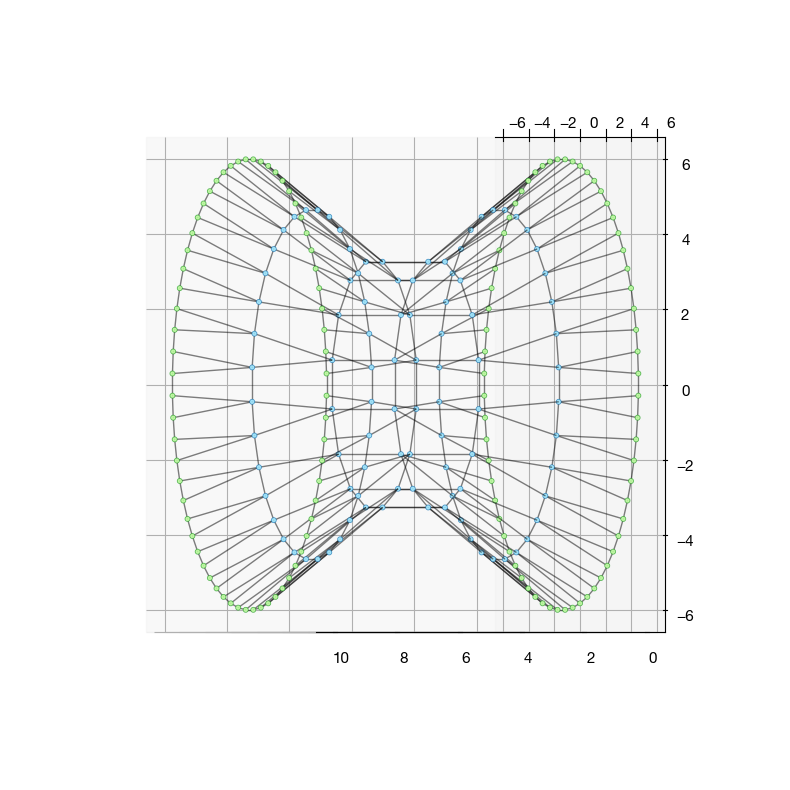

In [14]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': "tight"}
%matplotlib inline

config = loco.reload()

wormhole_graph = undecorated_wormhole(config=config)


# if export_outputs:
#     plt.gcf().savefig("outputs/undecorated_wormhole.pdf")

## Make Figure

Assemble the wormhole panel and entropy panels, fit the one-sided entropy curve, and save the figure.


In [15]:
def one_sided_entropy(length, beta = 1, central_charge=1, offset=0):

    entropy = (central_charge / 3) * np.log((beta / np.pi) * np.sinh(np.pi * length / beta)) + offset

    return entropy

def thermal_entropy(beta, total_length, central_charge=1):
    # see S.19 in the supplement
    return np.pi * central_charge * total_length / (3 * beta)

def alternative_one_sided_entropy(length, total_length, beta = 1, central_charge=1, offset=0):
    return thermal_entropy(beta, total_length, central_charge) + one_sided_entropy(total_length - length, beta, central_charge, offset)

Fitted parameters (one-sided wormhole):
  β = 2.90(10) \times 10^{1}
  c = 5.8(2)
  offset = 2.1(1)


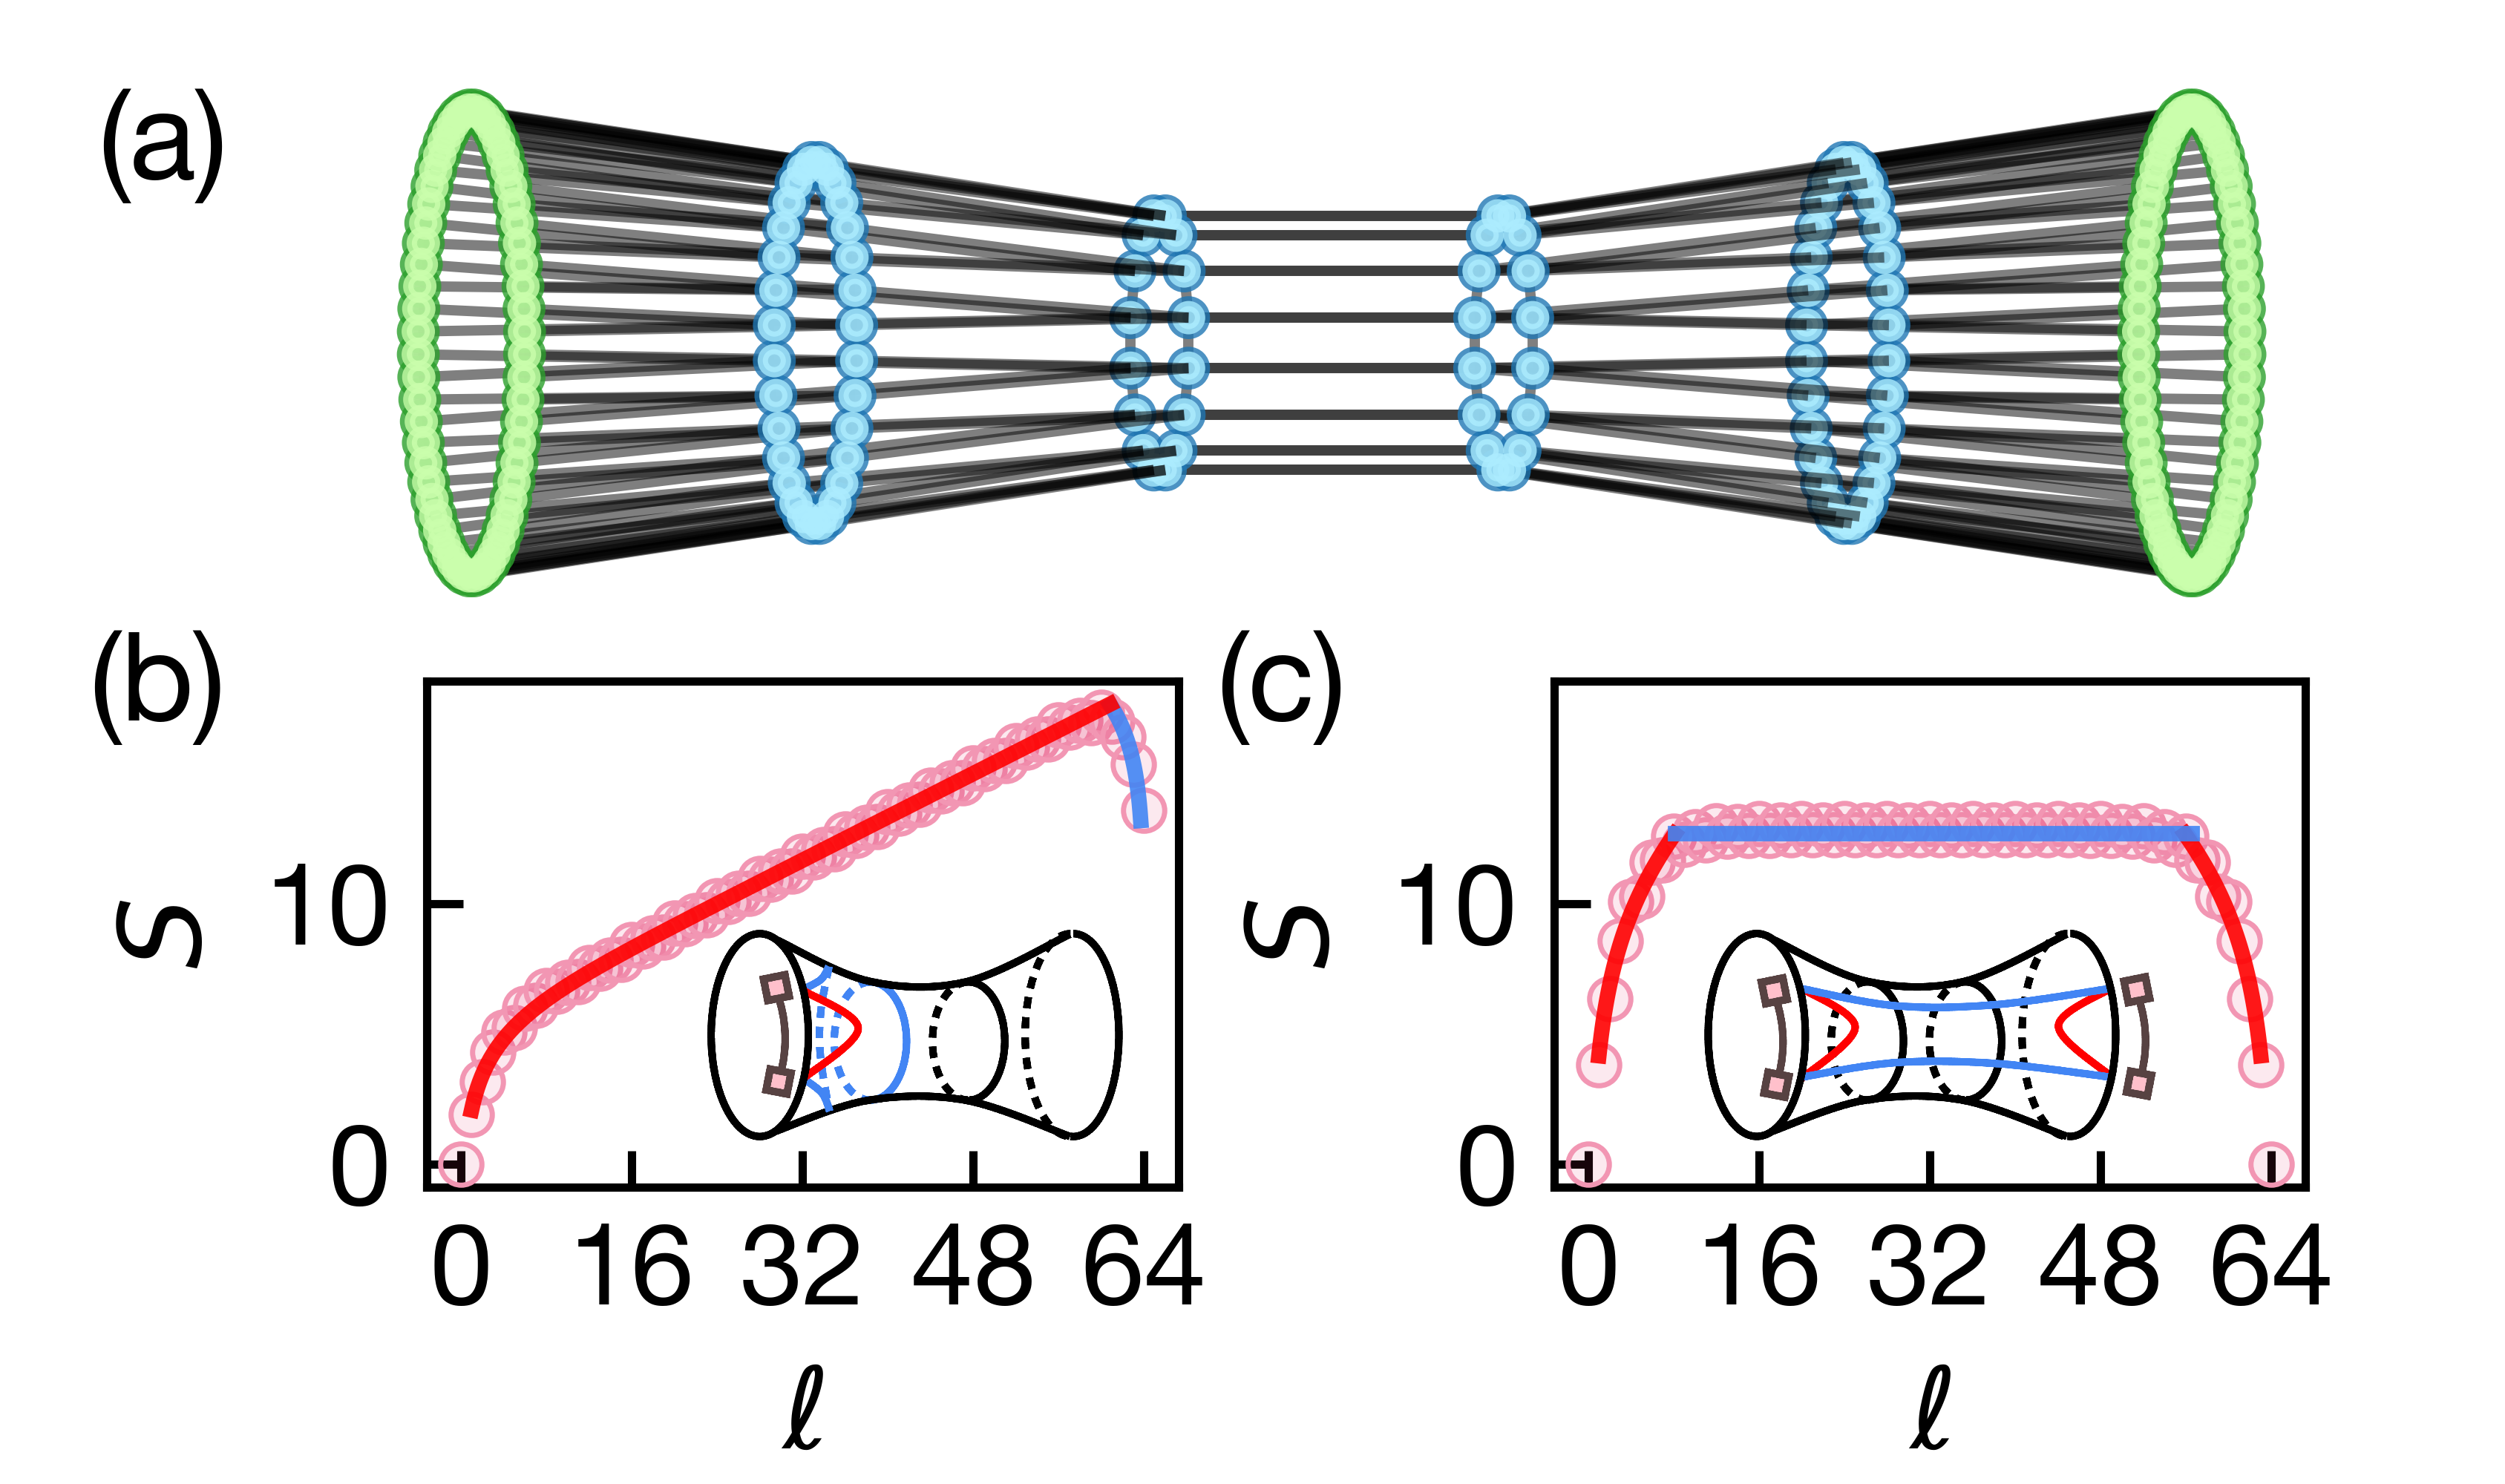

In [ ]:

config = loco.reload()

bottom_crop = 0.0
top_crop = 0.0
bbox = mpl.transforms.Bbox.from_bounds(0.1, bottom_crop, 3.375, 2 - top_crop - bottom_crop)

%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline

fig = plt.figure(figsize=(bbox.width, bbox.height + top_crop + bottom_crop), dpi=1000)

gs_overall = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1], wspace=0, left=0.2, top=0.95, right=0.95, bottom=0.2)


# this  should be a 3d ax
ax_wormhole = fig.add_subplot(gs_overall[0], projection='3d', computed_zorder=False)

wormhole_graph = undecorated_wormhole(ax=ax_wormhole, config=config, onesided=True)
# wormhole_graph = decorated_wormhole(ax=ax_wormhole, config=config, onesided=True)
wormhole_graph_twosided = undecorated_wormhole(ax=None, plot=False, config=config, onesided=False)

# ax_wormhole.set_axis_off()

gs_right = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs_overall[1],
    wspace=0.5
)

onesided_entropy_ax = fig.add_subplot(gs_right[0])
twosided_entropy_ax = fig.add_subplot(gs_right[1])

onesided_entropy_ax.sharey(twosided_entropy_ax) 


squeeze = 1/5
analysis = Analysis(wormhole_graph, is_decorated=False, couplingtime=1, global_presqueeze=squeeze, config=config)
analysis2 = Analysis(wormhole_graph_twosided, is_decorated=False, couplingtime=1, global_presqueeze=squeeze, config=config)

analysis.plot_entanglement_entropy(onesided_entropy_ax, include_ends=True, zorder=5, markersize=4, alpha=0.1)
analysis2.plot_entanglement_entropy(twosided_entropy_ax, include_ends=True, zorder=5, markersize=4, alpha=0.1)


fine_lengths = np.linspace(1, analysis.boundary_length*0.995, 1000)

# plot entanglement entropy

onesided_entropy_ax.set_ylabel("$S$")
onesided_entropy_ax.set_xlabel(r"$\ell$")

twosided_entropy_ax.set_ylabel("$S$")
twosided_entropy_ax.set_xlabel(r"$\ell$")


fig.text(0.0685, 0.94, f'(a)', 
        fontsize=config['subfigure-label']['font']['size'], fontweight='bold', va='top', ha='left')

onesided_entropy_ax.text(-0.45, 1.1, f'(b)', transform=onesided_entropy_ax.transAxes,
        fontsize=config['subfigure-label']['font']['size'], fontweight='bold', va='top', ha='left')

twosided_entropy_ax.text(-0.45, 1.1, f'(c)', transform=twosided_entropy_ax.transAxes,
        fontsize=config['subfigure-label']['font']['size'], fontweight='bold', va='top', ha='left')

zoom = 0.03
vertical_position = 0.3
img = plt.imread("inputs/onesided.png")          # keeps PNG transparency (RGBA)
imagebox = OffsetImage(img, zoom=zoom)  # controls displayed size

ab = AnnotationBbox(
    imagebox, (0.65, vertical_position),            # axes fraction
    xycoords="axes fraction",
    frameon=False,
    box_alignment=(0.5, 0.5),              # anchor at top-right of image
    zorder=10
)
onesided_entropy_ax.add_artist(ab)

img2 = plt.imread("inputs/twosided.png")          # keeps PNG transparency (RGBA)
imagebox2 = OffsetImage(img2, zoom=zoom)  # controls displayed size

ab = AnnotationBbox(
    imagebox2, (0.5, vertical_position),            # axes fraction
    xycoords="axes fraction",
    frameon=False,
    box_alignment=(0.5, 0.5),              # anchor at top-right of image
    zorder=10
)
twosided_entropy_ax.add_artist(ab)

ax_wormhole.set_box_aspect((1, 1.5, 6))
ax_wormhole.set_position([0.05, 0.05, 1, 1.4])
ax_wormhole.set_axis_off()

onesided_entropy_ax.set_xticks([0, 16, 32, 48, 64])
twosided_entropy_ax.set_xticks([0, 16, 32, 48, 64])

class FitParameters(NamedTuple):
    beta: float
    central_charge: float
    offset: float

# fit parameters for one-sidd wormhole
guess_params_onesided = FitParameters(
    beta=35,
    central_charge=5,
    offset=2
)

# fit the parameters to the one-sided wormhole using scipy.optimize.curve_fit

optimal_params, covariance = curve_fit(
    one_sided_entropy,
    analysis.region_sizes[1:-10],
    analysis.boundary_entropies[1:-10],
    p0=[guess_params_onesided.beta, guess_params_onesided.central_charge, guess_params_onesided.offset],
    bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf])
)

# Extract standard errors from covariance matrix
param_stderr = np.sqrt(np.diag(covariance))
beta_stderr, central_charge_stderr, offset_stderr = param_stderr

optimal_fit_onesided = FitParameters(*optimal_params)

# Print fit parameters with uncertainties
print("Fitted parameters (one-sided wormhole):")
print(f"  β = {format_with_uncertainty(optimal_fit_onesided.beta, beta_stderr)}")
print(f"  c = {format_with_uncertainty(optimal_fit_onesided.central_charge, central_charge_stderr)}")
print(f"  offset = {format_with_uncertainty(optimal_fit_onesided.offset, offset_stderr)}")

analytic_onesided_entropies = one_sided_entropy(
    fine_lengths, # analysis.boundary_length,
    beta=optimal_fit_onesided.beta, central_charge=optimal_fit_onesided.central_charge, offset=optimal_fit_onesided.offset
)

alternative_onesided_entropies = alternative_one_sided_entropy(
    fine_lengths, analysis.boundary_length, beta=optimal_fit_onesided.beta,
    central_charge=optimal_fit_onesided.central_charge, offset=optimal_fit_onesided.offset,
)

linewidth = 1.5

rt_color = (1, 0, 0)# config["graph"]["nodes"]["selected_boundary"]["ryu_takayanagi"]["color"]

# onesided_entropy_ax.plot(fine_lengths, one_sided_entropy(fine_lengths, analysis.boundary_length, beta=guess_params_onesided.beta, central_charge=guess_params_onesided.central_charge, offset=guess_params_onesided.offset), color='C1', linewidth=2, zorder=0)
onesided_entropy_ax.plot(
    fine_lengths[analytic_onesided_entropies < alternative_onesided_entropies],
    analytic_onesided_entropies[analytic_onesided_entropies < alternative_onesided_entropies],
    color=rt_color, linewidth=linewidth, zorder=10,
    alpha=0.9
)

# plot alternative one_sided entropy
onesided_entropy_ax.plot(
    fine_lengths[alternative_onesided_entropies < analytic_onesided_entropies],
    alternative_onesided_entropies[alternative_onesided_entropies < analytic_onesided_entropies],
    alpha=0.9, color="#4285f4", linewidth=linewidth, zorder=9,
)

# Using the analytic crossover to find the middle entropy
crossover_length = (optimal_fit_onesided.beta / np.pi) * np.arcsinh(1)
two_sided_middle_entropy = 2 * one_sided_entropy(
    crossover_length, beta=optimal_fit_onesided.beta,
    central_charge=optimal_fit_onesided.central_charge,
    offset=optimal_fit_onesided.offset
)


# mask = 2 * analytic_onesided_entropies < two_sided_middle_entropy
mask = np.sinh(np.pi * fine_lengths / optimal_fit_onesided.beta) < 1 



twosided_entropy_ax.plot(
    fine_lengths[mask],
    2 * analytic_onesided_entropies[mask], 
    alpha=0.9, color=rt_color, linewidth=linewidth, zorder=9,
)

twosided_entropy_ax.plot(
    analysis.boundary_length - fine_lengths[mask],
    2 * analytic_onesided_entropies[mask], 
    alpha=0.9, color=rt_color, linewidth=linewidth, zorder=9,
)

twosided_entropy_ax.plot(
    fine_lengths[~mask & ~mask[::-1]],
    np.ones_like(fine_lengths[~mask & ~mask[::-1]]) * two_sided_middle_entropy, 
    alpha=0.9, color="#4285f4", linewidth=linewidth, zorder=9,
)

plt.show()

if export_outputs := True:
    save_figure_with_hash(fig, "figures/figure_2_wormhole.pdf", bbox_inches=bbox)